Epoch 0, Loss = 55.618977
Epoch 100, Loss = 0.291338
Epoch 200, Loss = 0.058503
Epoch 300, Loss = 0.031485
Epoch 400, Loss = 0.013770
Epoch 500, Loss = 0.008569
Epoch 600, Loss = 0.007741
Epoch 700, Loss = 0.005421
Epoch 800, Loss = 0.003398
Epoch 900, Loss = 0.005306
Epoch 1000, Loss = 0.005082
Epoch 1100, Loss = 0.003743
Epoch 1200, Loss = 0.004835
Epoch 1300, Loss = 0.003686
Epoch 1400, Loss = 0.002673
Epoch 1500, Loss = 0.006027
Epoch 1600, Loss = 0.000805
Epoch 1700, Loss = 0.001916
Epoch 1800, Loss = 0.001407
Epoch 1900, Loss = 0.004171


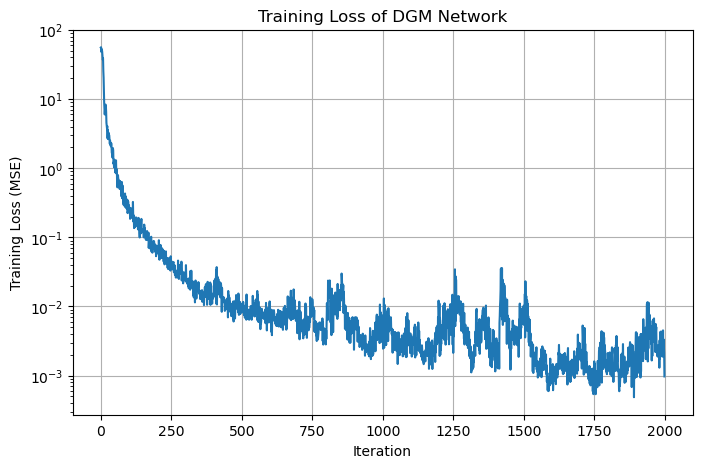

In [1]:
#Question2.1
import torch

from EX1_1xinyue import LQR

# -----------------------------
# Step 1: 初始化 LQR 模型
# -----------------------------


H = torch.tensor([[0.1, 0.0],
                  [0.0, 0.1]], dtype=torch.float32)

M = torch.eye(2)
C = torch.eye(2)
D = torch.eye(2)
R = torch.eye(2)

sigma = 0.2 * torch.eye(2)
T = 1.0

lqr = LQR(H, M, C, D, R, sigma, T)

# 时间网格（用于求 Riccati）会得到对应的矩阵S(ti)和标量g(ti),0<ti<T,0<=i<=200
time_grid = torch.linspace(0, T, 200)
lqr.solve_riccati(time_grid)


#第一步：先“做字典”

#在 time_grid 上把 Riccati 方程解出来。

#相当于先有一批已知点：
#t_i get S(t_i)
#t_i get g(t_i)


#第二步：再“查值”

#训练时随机来了一个时间 t=0.372，怎么办？

#就用插值在附近网格点之间估算：
#S(0.372)
#g(0.372)

#然后得到 v(0.372,x)。


# -----------------------------
# Step 2: 生成训练数据
# -----------------------------
def generate_training_data(N):
    """
    生成 supervised learning 数据：
    输入：(t, x)
    输出：v(t,x)

    N: 样本数量
    """

    # 采样 t ~ U[0,1]
    t = torch.rand(N, 1)

    # 采样 x ~ U([-3,3]^2)
    x = -3 + 6 * torch.rand(N, 2)

    # reshape 成题目要求 (batch,1,2),只是改变了形状，但是数值没有变，就是从[x1,x2] 变成[[x1,x2]]，就是有batch个样本，每个样本都是一个（1，2）的vector
    x_input = x.unsqueeze(1)#由(N,2)变为（N,1,2）

    # 用第一问算 value function
    y = lqr.value_function(t.squeeze(), x_input)   # shape (N,1) ,y(i)=v(x(i),t(i))，是真实值，真是的value function的值

    return t, x, y



from lib.dgm import Net_DGM   # 你的文件 :contentReference[oaicite:1]{index=1}

# -----------------------------
# 网络初始化
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dim_x = 2          # x 是二维
hidden_size = 100  # 题目要求

model = Net_DGM(dim_x=dim_x, dim_S=hidden_size).to(device)



import torch.nn as nn
import matplotlib.pyplot as plt

# -----------------------------
# 超参数
# -----------------------------
N_train = 5000 #生成5000个数据

epochs = 2000 #训练循环执行2000次
batch_size = 256 #每次更新用5000个数据里面随机抽取256个
learning_rate = 1e-3 #学习率，梯度下降步长

# 生成数据
t_data, x_data, y_data = generate_training_data(N_train)

# 放到 device
t_data = t_data.to(device)
x_data = x_data.to(device)
y_data = y_data.to(device)#这个是真实值

# optimizer + loss
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()

# 记录 loss
loss_history = []


# -----------------------------
# 训练循环
# -----------------------------
for epoch in range(epochs):

    # 随机 batch
    idx = torch.randint(0, N_train, (batch_size,))
    t_batch = t_data[idx]
    x_batch = x_data[idx]
    y_batch = y_data[idx]

    # -------------------------
    # forward 先猜一个参数（神经网络内部的参数，不是最开始的HJB的参数），用这个参数数值估计出的v，

    # -------------------------
    pred = model(t_batch, x_batch)   # (batch,1)
    # -------------------------
    # loss 看看估计的和真实值差多少

    # -------------------------
    loss = loss_fn(pred, y_batch)#y_batch是真实值（随机取得batch个的）
    # -------------------------
    # backward 根据这个loss，确定调整参数的方向
    # -------------------------
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    # 打印
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.6f}")



plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Training Loss (MSE)")
plt.title("Training Loss of DGM Network")
plt.yscale("log")   # 很重要，loss 会下降很多数量级
plt.grid()
plt.show()


Epoch 0, Loss = 3.751041
Epoch 100, Loss = 0.005468
Epoch 200, Loss = 0.001162
Epoch 300, Loss = 0.000586
Epoch 400, Loss = 0.000441
Epoch 500, Loss = 0.000366
Epoch 600, Loss = 0.000288
Epoch 700, Loss = 0.000279
Epoch 800, Loss = 0.000288
Epoch 900, Loss = 0.000218
Epoch 1000, Loss = 0.000191
Epoch 1100, Loss = 0.000218
Epoch 1200, Loss = 0.000167
Epoch 1300, Loss = 0.000131
Epoch 1400, Loss = 0.000153
Epoch 1500, Loss = 0.000116
Epoch 1600, Loss = 0.000160
Epoch 1700, Loss = 0.000122
Epoch 1800, Loss = 0.000102
Epoch 1900, Loss = 0.000101


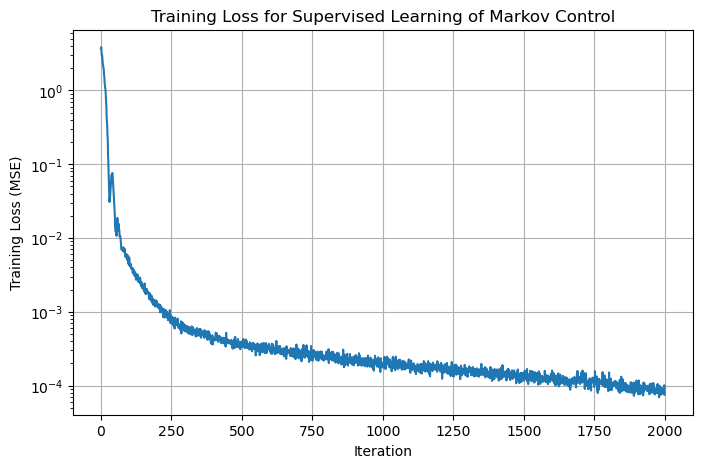

In [3]:
# Question 2.2
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from EX1_1xinyue import LQR
# 从你上传的 networks 文件里导入 FFN
from lib.networks import FFN


def generate_control_training_data(N):
    """
    生成 supervised learning 数据：
    输入: (t, x)
    输出: a(t,x)

    N: 样本数量
    """

    # 采样时间 t ~ U[0,1]
    t_ctrl = torch.rand(N, 1)

    # 采样状态 x ~ U([-3,3]^2)
    x_ctrl = -3 + 6 * torch.rand(N, 2)

    # 为了适配第一问 control() 的输入格式，把 x 从 (N,2) 变成 (N,1,2)
    x_input_ctrl = x_ctrl.unsqueeze(1)

    # 用第一问的最优控制函数生成真实标签
    # 输出 shape 应该是 (N,2)
    a_data = lqr.optimal_control(t_ctrl.squeeze(), x_input_ctrl)

    return t_ctrl, x_ctrl, a_data


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# FFN: input_dim=3, two hidden layers of size 100, output_dim=2
model_ctrl = FFN(
    sizes=[3, 100, 100, 2],   # 3 -> 100 -> 100 -> 2
    activation=nn.ReLU,       
    output_activation=nn.Identity,
    batch_norm=False
).to(device)


# -----------------------------
# 超参数
# -----------------------------
N_train = 5000
epochs = 2000
batch_size = 256
learning_rate = 1e-3

# 生成训练数据
t_data_ctrl, x_data_ctrl, a_data = generate_control_training_data(N_train)

# 把数据放到 device
t_data_ctrl = t_data_ctrl.to(device)   # (N,1)
x_data_ctrl = x_data_ctrl.to(device)   # (N,2)
a_data = a_data.to(device)             # (N,2)

# 定义优化器和损失函数
optimizer = torch.optim.Adam(model_ctrl.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()

# 用来记录训练过程中每一步的 loss
loss_history = []


# -----------------------------
# 训练循环
# -----------------------------
for epoch in range(epochs):

    # 从训练集里随机抽一个 mini-batch
    idx = torch.randint(0, N_train, (batch_size,))

    t_batch_ctrl = t_data_ctrl[idx]   # (batch,1)
    x_batch_ctrl = x_data_ctrl[idx]   # (batch,2)
    a_batch = a_data[idx]             # (batch,2)，真实 control 标签

    # 拼接输入
    input_batch_ctrl = torch.cat([t_batch_ctrl, x_batch_ctrl], dim=1)

    # forward：预测 control
    a_pred = model_ctrl(input_batch_ctrl)   # (batch,2)

    # loss：MSE
    loss = loss_fn(a_pred, a_batch)

    # backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 记录 loss
    loss_history.append(loss.item())

    # 打印
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.6f}")


# -----------------------------
# 画图
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Training Loss (MSE)")
plt.title("Training Loss for Supervised Learning of Markov Control")
plt.yscale("log")
plt.grid()
plt.show()